Effect size (Cohen's d): -1.9365
Sample size needed in each group: 5.34


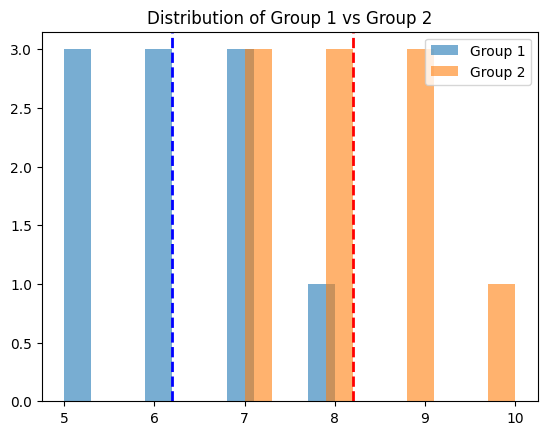

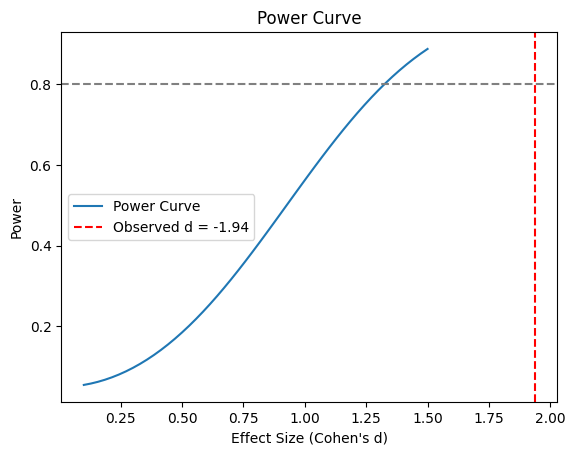

In [1]:
# Test Group 1 vs Test Group 2

from math import sqrt
from statsmodels.stats.power import TTestIndPower
import numpy as np
import matplotlib.pyplot as plt

# Raw data: replace the values below with the desired values for each respective group here
group1 = [5, 6, 7, 5, 6, 7, 8, 6, 5, 7]   # Test Group 1
group2 = [7, 8, 9, 8, 7, 9, 10, 8, 9, 7]  # Test Group 2

# Sample sizes
n1 = len(group1)
n2 = len(group2)

# Means
u1 = np.mean(group1)
u2 = np.mean(group2)

# Variances
s1 = np.var(group1, ddof=1)
s2 = np.var(group2, ddof=1)

# Pooled standard deviation
pooled_std = sqrt(((n1 - 1) * (s1) + (n2 - 1) * (s2)) / (n1 + n2 - 2))

# Effect size (Cohen's d)
d = (u1 - u2) / pooled_std
print(f"Effect size (Cohen's d): {d:.4f}")

# Power analysis
alpha = 0.05
power = 0.8
analysis = TTestIndPower()

try:
    sample_size = analysis.solve_power(effect_size=abs(d), alpha=alpha, power=power,
                                       ratio=n2/n1, alternative='two-sided')
    print(f'Sample size needed in each group: {sample_size:.2f}')
except Exception as e:
    print(f"Power analysis failed: {e}")

# Visuals
# Distribution comparison
plt.hist(group1, bins=10, alpha=0.6, label="Group 1")
plt.hist(group2, bins=10, alpha=0.6, label="Group 2")
plt.axvline(u1, color="blue", linestyle="dashed", linewidth=2)
plt.axvline(u2, color="red", linestyle="dashed", linewidth=2)
plt.title("Distribution of Group 1 vs Group 2")
plt.legend()
plt.show()

# Power curve
effect_sizes = np.linspace(0.1, 1.5, 50)
powers = analysis.power(effect_size=effect_sizes, nobs1=n1, alpha=alpha, ratio=n2/n1)
plt.plot(effect_sizes, powers, label="Power Curve")
plt.axhline(y=0.8, color="gray", linestyle="--")
plt.axvline(x=abs(d), color="red", linestyle="--", label=f"Observed d = {d:.2f}")
plt.title("Power Curve")
plt.xlabel("Effect Size (Cohen's d)")
plt.ylabel("Power")
plt.legend()
plt.show()
